# 🏠 Airbnb Market Analysis in European Cities

This project aims to analyze Airbnb listing data across multiple European cities to understand the factors influencing pricing, customer satisfaction, and listing characteristics.

The dataset includes listings from different cities, separated into weekdays and weekends, allowing for comparative analysis of pricing behavior across time and location.

## 🎯 Objective

The main objective of this project is to identify and understand the most important drivers of Airbnb prices across European cities.

Through exploratory data analysis and business-focused insights, this project seeks to:

- Identify the main factors influencing listing prices
- Understand how location affects pricing
- Compare pricing behavior across cities and day types
- Analyze the relationship between price and guest satisfaction
- Evaluate the impact of property characteristics on price
- Provide practical recommendations for Airbnb hosts and travelers

## ❓ Key Questions

### 💰 Pricing Drivers
1. What are the strongest factors influencing Airbnb prices across European cities?
2. How do location, room type, and property size affect listing prices?

### 📍 Location & Accessibility
3. How does distance from the city center impact Airbnb pricing?
4. Does proximity to metro stations influence listing prices?

### 🏙️ Cross-City Market Intelligence
5. Which cities are the most expensive, and what factors explain these differences?
6. Which cities offer the best value for money based on price and guest satisfaction?

### 🏠 Property Segmentation
7. How do room types (entire home, private room, shared room) affect pricing?

8. Are larger properties (more bedrooms / higher capacity) always priced higher?

### ⭐ Customer Satisfaction
9. Are higher-priced listings associated with better guest satisfaction?
10. Which factors contribute most to higher guest satisfaction?

### 📆 Time-Based Pricing Strategy
11. How much of a weekend price premium exists across different cities?
12. Which cities show the strongest weekend price increase?

### 💡 Business Recommendations
13. What pricing strategies could Airbnb hosts adopt based on city, location, and property type?
14. How can hosts improve competitiveness while maintaining strong guest satisfaction?



In [1]:
## Importing neccassry libarires  


import pandas as pd
import glob
import os

In [4]:
## Readibg the 20 files in the path and checking if all are readable 

import glob

files = sorted(glob.glob(r"C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\*.csv"))

print("Number of files:", len(files))
print(files)


Number of files: 20
['C:\\Users\\ELFYR\\Desktop\\Islam\\airbnb-pricing-analysis-capstone\\Airbnb Data Set\\Data\\raw\\amsterdam_weekdays.csv', 'C:\\Users\\ELFYR\\Desktop\\Islam\\airbnb-pricing-analysis-capstone\\Airbnb Data Set\\Data\\raw\\amsterdam_weekends.csv', 'C:\\Users\\ELFYR\\Desktop\\Islam\\airbnb-pricing-analysis-capstone\\Airbnb Data Set\\Data\\raw\\athens_weekdays.csv', 'C:\\Users\\ELFYR\\Desktop\\Islam\\airbnb-pricing-analysis-capstone\\Airbnb Data Set\\Data\\raw\\athens_weekends.csv', 'C:\\Users\\ELFYR\\Desktop\\Islam\\airbnb-pricing-analysis-capstone\\Airbnb Data Set\\Data\\raw\\barcelona_weekdays.csv', 'C:\\Users\\ELFYR\\Desktop\\Islam\\airbnb-pricing-analysis-capstone\\Airbnb Data Set\\Data\\raw\\barcelona_weekends.csv', 'C:\\Users\\ELFYR\\Desktop\\Islam\\airbnb-pricing-analysis-capstone\\Airbnb Data Set\\Data\\raw\\berlin_weekdays.csv', 'C:\\Users\\ELFYR\\Desktop\\Islam\\airbnb-pricing-analysis-capstone\\Airbnb Data Set\\Data\\raw\\berlin_weekends.csv', 'C:\\Users\\ELF

In [5]:
## Exploring the data 
df_sample = pd.read_csv(files[4])

df_sample.head()

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,474.317499,Entire home/apt,False,False,4.0,False,0,1,10.0,91.0,1,1.111996,0.630491,526.469420,17.942927,915.587083,20.154890,2.17556,41.39624
1,1,169.897829,Private room,False,True,2.0,True,1,0,10.0,88.0,1,1.751839,0.124017,320.127526,10.910462,794.277350,17.484489,2.14906,41.38714
2,2,161.984779,Private room,False,True,4.0,False,0,1,9.0,88.0,1,1.670493,0.080322,344.073936,11.726595,840.673617,18.505814,2.15357,41.37859
3,3,367.956804,Entire home/apt,False,False,3.0,False,0,1,10.0,91.0,1,1.475847,0.093107,400.057449,13.634603,946.589884,20.837357,2.16839,41.37390
4,4,196.895292,Private room,False,True,3.0,False,1,0,9.0,91.0,1,1.855452,0.272486,346.042245,11.793678,792.296039,17.440874,2.15238,41.37699


In [6]:
## Exploring the format for each column and check if each column has a correct value
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 1555 entries, 0 to 1554
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1555 non-null   int64  
 1   realSum                     1555 non-null   float64
 2   room_type                   1555 non-null   str    
 3   room_shared                 1555 non-null   bool   
 4   room_private                1555 non-null   bool   
 5   person_capacity             1555 non-null   float64
 6   host_is_superhost           1555 non-null   bool   
 7   multi                       1555 non-null   int64  
 8   biz                         1555 non-null   int64  
 9   cleanliness_rating          1555 non-null   float64
 10  guest_satisfaction_overall  1555 non-null   float64
 11  bedrooms                    1555 non-null   int64  
 12  dist                        1555 non-null   float64
 13  metro_dist                  1555 non-null   

In [7]:
## Checking intial statsics 
df_sample.describe()

,Unnamed: 0,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000
mean,777.000000,288.391667,2.756270,0.376849,0.350482,9.285531,90.929260,1.216720,2.117302,0.434875,464.371805,15.826540,877.664048,19.320087,2.168975,41.393308
std,449.034149,321.180435,1.276615,0.484752,0.477275,1.007445,8.695707,0.569475,1.351517,0.275846,268.318982,9.144744,461.294504,10.154512,0.019657,0.015947
min,0.000000,69.588289,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.119903,0.013004,93.820461,3.197553,159.835498,3.518471,2.105190,41.349540
25%,388.500000,161.984779,2.000000,0.000000,0.000000,9.000000,88.000000,1.000000,1.090570,0.252128,282.772255,9.637335,494.391320,10.883075,2.156000,41.381215
50%,777.000000,208.532129,2.000000,0.000000,0.000000,10.000000,93.000000,1.000000,1.751839,0.370507,389.198464,13.264511,801.812049,17.650351,2.170710,41.390360
75%,1165.500000,335.373659,3.000000,1.000000,1.000000,10.000000,97.000000,1.000000,2.949202,0.554220,591.594276,20.162487,1211.256634,26.663486,2.179375,41.404000
max,1554.000000,6943.700980,6.000000,1.000000,1.000000,10.000000,100.000000,6.000000,8.443957,2.402779,2934.133441,100.000000,4542.754150,100.000000,2.225520,41.463080


In [8]:
## Advanced exploration for the data for each file 

for file in files:
    df_temp = pd.read_csv(file)
    
    print(f"\nFile: {file}")
    print("Shape:", df_temp.shape)
    print("Columns:", df_temp.columns.tolist())


File: C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\amsterdam_weekdays.csv
Shape: (1103, 20)
Columns: ['Unnamed: 0', 'realSum', 'room_type', 'room_shared', 'room_private', 'person_capacity', 'host_is_superhost', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat']

File: C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\amsterdam_weekends.csv
Shape: (977, 20)
Columns: ['Unnamed: 0', 'realSum', 'room_type', 'room_shared', 'room_private', 'person_capacity', 'host_is_superhost', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat']

File: C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\athens_weekdays.csv
Shape: (2653, 2

In [9]:
## Checking for duplicates 
df_sample.duplicated().sum()

np.int64(0)

In [10]:
## Checking for null values 
df_sample.isnull().values.any()

np.False_

In [11]:
df_sample[df_sample.isnull().any(axis=1)]

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat


In [12]:
## Converting the person capacity format from float to integer 


df_sample['person_capacity'] = df_sample['person_capacity'].astype(int)

## Merging the data

After exploring a sample file and validating its structure, the next step is to merge all listing files into unified datasets.

The data will be organized into:
- one dataset for all weekday listings
- one dataset for all weekend listings
- one final combined dataset for all cities and day types

This structure will make the analysis more efficient and allow direct comparison across cities and between weekdays and weekends.

### 1. Separating files by day type

In this step, we separate all CSV files into two groups:
- weekday files
- weekend files

This allows us to first combine all weekday listings together, then all weekend listings, before creating one final dataset for analysis.

In [13]:
weekdays_files = [f for f in files if "weekdays" in f]
weekends_files = [f for f in files if "weekends" in f]

print("Weekday files:", len(weekdays_files))
print("Weekend files:", len(weekends_files))

Weekday files: 10
Weekend files: 10


### 2. Merging all weekday files

Here, we read all weekday files and combine them into one dataset.

For each file, we also extract the city name from the file name and create:
- a `city` column
- a `day_type` column set to `"weekday"`

This makes the data ready for city-level and day-type comparisons later in the analysis.

In [14]:
df_weekdays_list = []

for file in weekdays_files:
    df_temp = pd.read_csv(file)
    
    city = file.split("_")[0]
    
    df_temp["city"] = city
    df_temp["day_type"] = "weekday"
    
    df_weekdays_list.append(df_temp)

df_weekdays = pd.concat(df_weekdays_list, ignore_index=True)

df_weekdays.head()

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,...,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,city,day_type
0,0,194.033698,Private room,False,True,2.0,False,1,0,10.0,...,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,4.90569,52.41772,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday
1,1,344.245776,Private room,False,True,4.0,False,0,0,8.0,...,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,4.90005,52.37432,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday
2,2,264.101422,Private room,False,True,2.0,False,0,1,9.0,...,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,4.97512,52.36103,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday
3,3,433.529398,Private room,False,True,4.0,False,0,1,9.0,...,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,4.89417,52.37663,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday
4,4,485.552926,Private room,False,True,2.0,True,0,0,10.0,...,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,4.90051,52.37508,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday


### 3. Merging all weekend files

In this step, we repeat the same process for weekend files.

Each file is loaded, the city name is extracted, and two new columns are added:
- `city`
- `day_type` set to `"weekend"`

Then, all weekend datasets are merged into one dataframe.

In [15]:
df_weekends_list = []

for file in weekends_files:
    df_temp = pd.read_csv(file)
    
    city = file.split("_")[0]
    
    df_temp["city"] = city
    df_temp["day_type"] = "weekend"
    
    df_weekends_list.append(df_temp)

df_weekends = pd.concat(df_weekends_list, ignore_index=True)

df_weekends.head()

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,...,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,city,day_type
0,0,319.640053,Private room,False,True,2.0,False,0,1,9.0,...,4.763360,0.852117,110.906123,5.871971,136.982208,11.941560,4.84639,52.34137,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekend
1,1,347.995219,Private room,False,True,2.0,False,0,1,9.0,...,5.748310,3.651591,75.275937,3.985516,95.386468,8.315410,4.97512,52.36103,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekend
2,2,482.975183,Private room,False,True,4.0,False,0,1,9.0,...,0.384872,0.439852,493.272517,26.116521,875.114817,76.289005,4.89417,52.37663,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekend
3,3,485.552926,Private room,False,True,2.0,True,0,0,10.0,...,0.544723,0.318688,552.849514,29.270850,815.303994,71.074937,4.90051,52.37508,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekend
4,4,2771.541724,Entire home/apt,False,False,4.0,True,0,0,10.0,...,1.686798,1.458399,208.809162,11.055489,272.315202,23.739349,4.88467,52.38749,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekend


### 4. Creating the final master dataset

After building separate datasets for weekdays and weekends, we combine them into one final master dataset called `df_all`.

This final dataset contains:
- all cities
- both weekday and weekend listings
- a `city` column
- a `day_type` column

This is the main dataset that will be used for all further cleaning, analysis, and visualization.

In [16]:
df_all = pd.concat([df_weekdays, df_weekends], ignore_index=True)

df_all.head()

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,...,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,city,day_type
0,0,194.033698,Private room,False,True,2.0,False,1,0,10.0,...,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,4.90569,52.41772,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday
1,1,344.245776,Private room,False,True,4.0,False,0,0,8.0,...,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,4.90005,52.37432,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday
2,2,264.101422,Private room,False,True,2.0,False,0,1,9.0,...,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,4.97512,52.36103,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday
3,3,433.529398,Private room,False,True,4.0,False,0,1,9.0,...,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,4.89417,52.37663,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday
4,4,485.552926,Private room,False,True,2.0,True,0,0,10.0,...,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,4.90051,52.37508,C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-an...,weekday


### 5. Checking dataset sizes

Before continuing, we verify the number of rows and columns in each merged dataset:
- weekday dataset
- weekend dataset
- final combined dataset

This helps confirm that the merge was successful.

In [17]:
print("df_weekdays shape:", df_weekdays.shape)
print("df_weekends shape:", df_weekends.shape)
print("df_all shape:", df_all.shape)

df_weekdays shape: (25500, 22)
df_weekends shape: (26207, 22)
df_all shape: (51707, 22)


## Final cleaning of the merged dataset

Now that all files have been merged into one dataset, we perform the final cleaning steps needed before starting the analysis.

These steps include:
- removing unnecessary columns
- renaming columns for readability
- standardizing data types
- checking for duplicates and missing values again

In [18]:
df_all = df_all.drop(columns=["Unnamed: 0"])

In [19]:
df_all = df_all.rename(columns={
    "realSum": "price",
    "guest_satisfaction_overall": "rating"
})

In [20]:
df_all["person_capacity"] = df_all["person_capacity"].astype(int)

In [21]:
df_all.duplicated().sum()

np.int64(0)

In [22]:
df_all.isnull().sum()

price                 0
room_type             0
room_shared           0
room_private          0
person_capacity       0
host_is_superhost     0
multi                 0
biz                   0
cleanliness_rating    0
rating                0
bedrooms              0
dist                  0
metro_dist            0
attr_index            0
attr_index_norm       0
rest_index            0
rest_index_norm       0
lng                   0
lat                   0
city                  0
day_type              0
dtype: int64

In [23]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 51707 entries, 0 to 51706
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               51707 non-null  float64
 1   room_type           51707 non-null  str    
 2   room_shared         51707 non-null  bool   
 3   room_private        51707 non-null  bool   
 4   person_capacity     51707 non-null  int64  
 5   host_is_superhost   51707 non-null  bool   
 6   multi               51707 non-null  int64  
 7   biz                 51707 non-null  int64  
 8   cleanliness_rating  51707 non-null  float64
 9   rating              51707 non-null  float64
 10  bedrooms            51707 non-null  int64  
 11  dist                51707 non-null  float64
 12  metro_dist          51707 non-null  float64
 13  attr_index          51707 non-null  float64
 14  attr_index_norm     51707 non-null  float64
 15  rest_index          51707 non-null  float64
 16  rest_index_norm

### 13. Verifying categorical fields

At this stage, we confirm that all expected cities are included in the final dataset and that weekday and weekend records are labeled correctly.

This ensures that the merged dataset is complete and ready for exploratory data analysis.

In [24]:
print(df_all["city"].unique())
print(df_all["day_type"].value_counts())

<StringArray>
['C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\amsterdam',
    'C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\athens',
 'C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\barcelona',
    'C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\berlin',
  'C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\budapest',
    'C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\lisbon',
    'C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\london',
     'C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\paris',
      'C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Data Set\Data\raw\rome',
    'C:\Users\ELFYR\Desktop\Islam\airbnb-pricing-analysis-capstone\Airbnb Dat

In [25]:
df_all.to_csv("airbnb_cleaned.csv", index=False)

## Data pipeline summary

The project workflow included:
- loading and exploring raw Airbnb data files
- validating structure and data quality
- merging weekday and weekend files
- creating a unified master dataset
- cleaning and standardizing the final data
- preparing the data for exploratory analysis


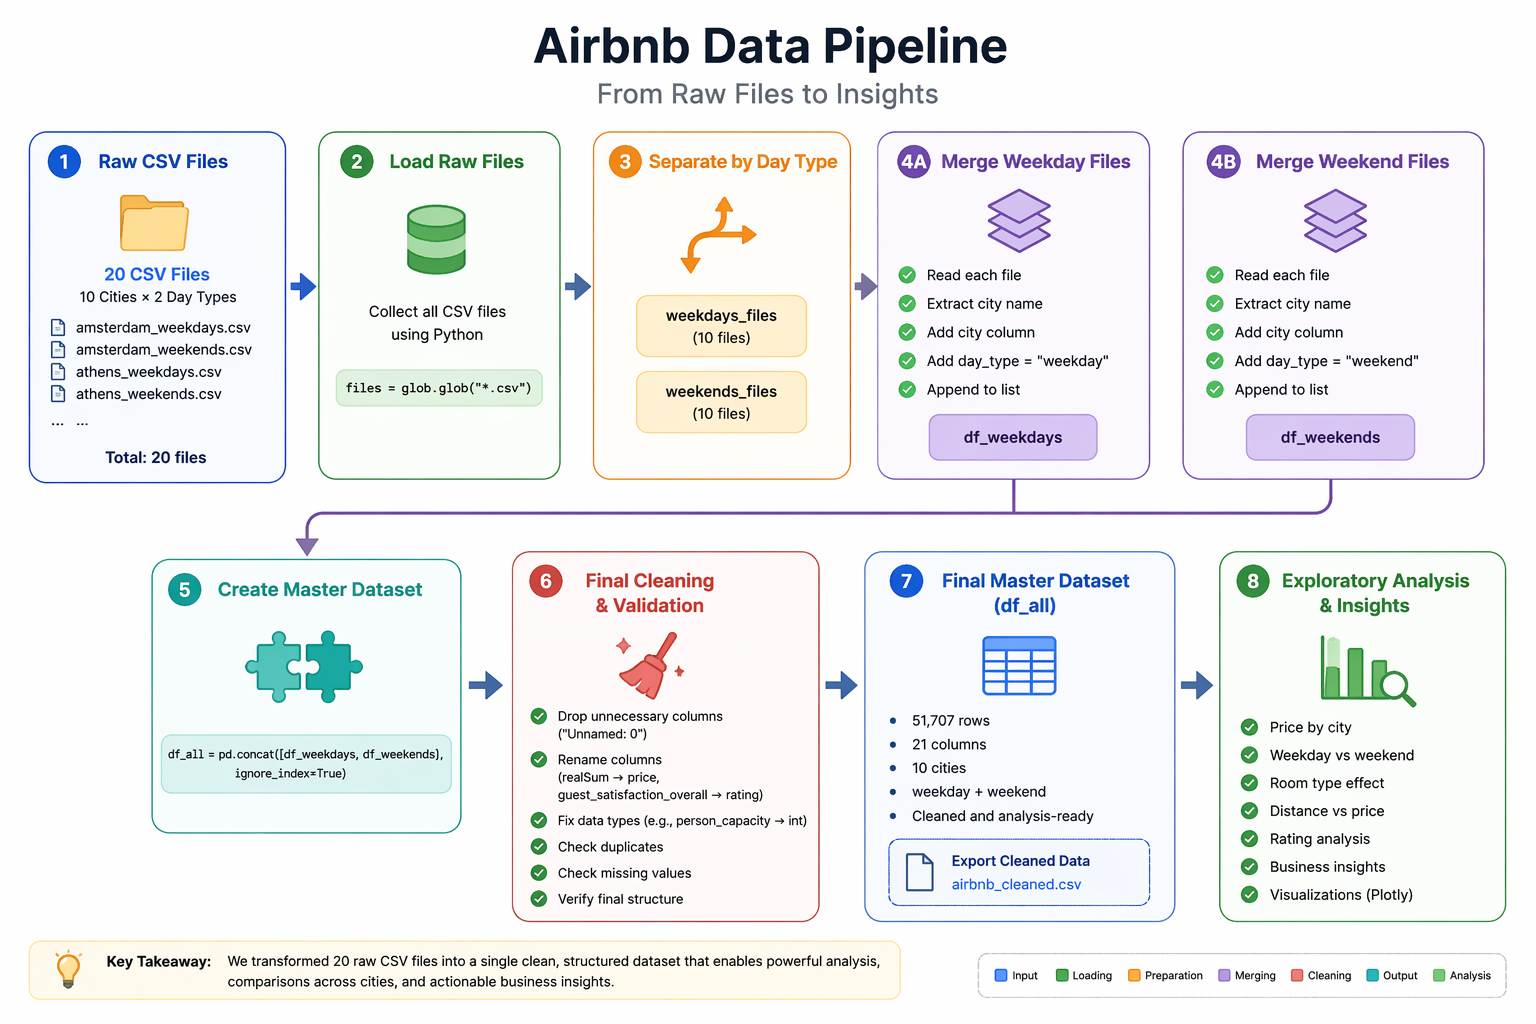

# Exploratory Data Analysis (EDA)

Now that the final dataset has been cleaned and validated, the next step is to explore the data in order to identify pricing patterns, compare cities, analyze weekday vs weekend differences, and understand how listing characteristics influence price and guest satisfaction.